# ExplainPhish: Excel Phishing Detection Tutorial & Research Benchmark
> **A Comprehensive, Scientifically Rigorous Educational Guide for University Students & Lecturers**

This notebook provides an explainable AI (XAI) and machine learning framework for detecting malicious and phishing Excel spreadsheets (`.xlsx`, `.xlsm`, `.xls`) using static structural, macro, and content features extracted from the **CIC-Trap4Phish2025** benchmark.

---

### 🎓 Guide for University Students & Lecturers

#### 📖 For Students: What You Will Learn
1. **How Attackers Weaponize Spreadsheets**: Phishing emails frequently deliver invoice or payroll spreadsheets containing malicious VBA macros, DDE formula execution (`=cmd|...`), or remote templates designed to download secondary malware.
2. **Why Static Analysis is Safe & Fast**: Instead of executing macros in an isolated sandbox (which can be evaded by sandbox-detection malware), static feature extraction analyzes XML structures and macro token counts safely in milliseconds.
3. **How Does the Machine Learn?**:
   - We extract 9 security attributes (e.g., macro vocabulary size, arithmetic operator counts, string cell counts, remote template flags).
   - `StandardScaler` standardizes each feature into a z-score ($z = \frac{x - \mu}{\sigma}$).
   - We train 6 machine learning models: Logistic Regression, Decision Tree, Random Forest, XGBoost, LightGBM, and Neural Network (MLP).
4. **Why Multi-Model Consensus (Voting)?**: Combining predictions across multiple diverse models provides superior accuracy and robustness against adversarial evasion.

#### 👨‍🏫 For Lecturers: Pedagogical Highlights
- **Strict Leakage Prevention**: Stratified splitting reserves an untouched 25% test set (N = 5,000). Scaling and preprocessing are strictly fitted inside 5-fold cross-validation folds.
- **Collinearity Defense**: Excludes `macro_chr_count` to eliminate multicollinearity with `macro_token_count`.
- **Hybrid Threat Verification**: Demonstrates how machine learning predictions are augmented by structural safety checks (verifying VBA project streams, OLE packages, and external relationship schemas).
- **Production Pipeline Export**: Serializes all trained models (`.joblib`), scalers, and metadata for instant inference in the `InterfaceExplainPhish` engine.

---

### 📊 Dataset & Benchmark Facts at a Glance
| Metric / Property | Benchmark Value | Description |
| :--- | :--- | :--- |
| **Total Samples** | **20,000 records** | CIC-Trap4Phish2025 Excel benchmark |
| **Class Distribution** | **10,000 Phishing (50.0%) vs. 10,000 Benign (50.0%)** | Perfectly balanced target distribution |
| **Active Features** | **9 discriminative static features** | Macro syntax, cell structure, and template indicators |
| **Development Split** | **75% (15,000 samples)** | 5-Fold Stratified Cross-Validation & hyperparameter tuning |
| **Final Test Split** | **25% (5,000 samples)** | Untouched holdout test set |
| **Evaluation Metrics** | **ROC-AUC, PR-AUC, Accuracy, Precision, Recall, F1** | Evaluated across 7 model configurations |

---

## 📑 Table of Contents (Organized Educational Curriculum)

```
ExplainPhish Excel Curriculum Structure:
├── Phase 1: Environment & Loading ──── [Sections 1 - 2]
├── Phase 2: Data Exploration & EDA ─── [Sections 3 - 4]
├── Phase 3: Modeling & Benchmark ───── [Section 5]
├── Phase 4: Production & Verification ─ [Sections 6 - 8]
```

### [1. Setup & Environment](#setup) *(Fundamental)*
- [1.1 Import Libraries](#import_libraries) — Environment configuration, random seeds, and styling.
- [1.2 Adaptive Path Resolution](#path_config) — Dynamic local & Google Colab directory resolution.

### [2. Loading the Data & Data Overview](#loading_data) *(Data Ingestion)*
- [2.1 Raw Loading](#raw_loading) — Ingesting `Excel_Top10_Features.csv` (20,000 records).
- [2.2 Data Cleaning & Stratified Splitting](#data_cleaning) — Multicollinearity removal and preliminary validation.
- [2.3 Feature Inventory & Data Types](#feature_inventory) — Verifying 64-bit float and integer datatypes.
- [2.4 Missing Value Analysis & Completeness Verification](#missing_analysis) — 100% completeness audit (0 missing values).
- [2.5 Summary & Descriptive Statistics](#descriptive_stats) — Distribution metrics (mean, std, percentiles).
- [2.6 Target Class Balance Analysis](#class_balance) — Verifying 50/50 balance across labels.
- [2.7 Excel Feature Definitions & Threat Relevance](#feature_definitions) — Cybersecurity threat relevance for each attribute.

### [3. Visualizing and Understanding the Data](#sec3) *(Exploratory Data Analysis)*
- [3.1 Checking Missing Values](#sec3_1) — Visual missingness verification.
- [3.2 Visualization and Analysis of Each Feature](#sec3_2) — Detailed distributional audits.
  - [3.2.1 Skewness & Distribution Evenness Assessment](#sec3_2_1) — Quantifying long-tail skewness.
  - [3.2.2 Full Feature Distribution Overview (Grid Visualization)](#sec3_2_2) — 9-attribute distribution plots.
  - [3.2.3 TARGET Column (Class Evenness & Distribution)](#sec3_2_3) — Visual class balance charts.
  - [3.2.4 Macro Complexity Attributes (`macro_token_count` & `macro_vocab_size`)](#sec3_2_4) — Macro obfuscation indicators.
  - [3.2.5 Heavy-Tailed Attributes: Raw vs. Logarithmic Transformation](#sec3_2_5) — Log-scaling benefits.
  - [3.2.6 Cell Structure & Remote Template Infiltration](#sec3_2_6) — Remote injection risk analysis.
  - [3.2.7 Comprehensive Evenness Summary Table & Correlation Heatmap](#sec3_2_7) — Feature correlation matrix.
- [3.3 Summary Findings & Next Steps](#sec3_3) — Synthesis of EDA findings.

### [4. Preprocessing and Feature Creation](#sec4) *(Data Engineering)*
- Defensive log transformations and standardization pipeline design.

### [5. Building the Machine Learning Models](#sec5) *(Model Development)*
- [5.1 Leakage-Resistant 75%/25% Train/Test Split](#sec5_1) — 15,000 train vs. 5,000 test holdout split.
- [5.2 Cross-Validation Framework & Baseline Models](#sec5_2) — Logistic Regression, Decision Tree, Baseline Random Forest.
- [5.3 Advanced Models: XGBoost, LightGBM & Neural Network (MLP)](#sec5_3) — Boosted trees and neural classifiers.
- [5.4 Hyperparameter Optimization (Random Forest Tuning)](#sec5_4) — RandomizedSearchCV parameter tuning.
- [5.5 Comprehensive Model Comparison Table](#sec5_5) — Leaderboard ranking across all architectures.
- [5.6 Final Model Assembly](#sec5_6) — Training final production estimators on full development split.

### [6. Model Export & Prediction Results](#sec6) *(Production Engineering)*
- Exporting model bundle (`.joblib`), scaler, metadata, and standardized datasets to disk.

### [7. Final Test Set Evaluation & Confusion Matrix Grid](#sec7) *(Evaluation)*
- Unbiased evaluation on the 5,000 holdout test set with 7-model confusion matrix grid.

### [8. Research Limitations & Future Roadmap](#sec8) *(Academic Discussion)*
- Discussion of adversarial macro obfuscation, OLE legacy limits, and future roadmap.


<a id="setup" name="setup"></a>
## 1. Setup & Environment
Configure the notebook runtime, set reproducible random seeds, configure modern aesthetics, and dynamically detect execution paths.


<a id="import_libraries" name="import_libraries"></a>
### 1.1 Import Libraries
We import `pandas` for tabular data manipulation, `numpy` for numerical calculations, `matplotlib` and `seaborn` for visualizations, and `pathlib` for flexible cross-platform path resolution.


In [35]:
import os
import sys
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Global reproducibility seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Visual formatting configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: "%.4f" % x)

print("Environment configured successfully with consistent visual theme and RANDOM_SEED = 42!")


Environment configured successfully with consistent visual theme and RANDOM_SEED = 42!


<a id="path_config" name="path_config"></a>
### 1.2 Adaptive Path Resolution
Dynamically search candidate locations for `Excel_Top10_Features.csv` across Google Colab and local environments.


In [36]:
# Adaptive path detection for local environments and Google Colab
current_dir = Path(os.getcwd())

candidate_paths = [
    current_dir / "data" / "excel" / "Excel_Top10_Features.csv",
    current_dir / "googleCollab" / "data" / "excel" / "Excel_Top10_Features.csv",
    Path("data/excel/Excel_Top10_Features.csv"),
    Path("googleCollab/data/excel/Excel_Top10_Features.csv"),
    Path("/content/drive/MyDrive/ExplainPhish/data/excel/Excel_Top10_Features.csv"),
    Path("/content/Excel_Top10_Features.csv"),
]

data_path = None
for p in candidate_paths:
    if p.exists():
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError("Could not find Excel_Top10_Features.csv. Please check the data directory.")

print(f"Data file successfully resolved at: {data_path.resolve()}")


Data file successfully resolved at: D:\codingProject\ExplainPhish\googleCollab\data\excel\Excel_Top10_Features.csv


<a id="loading_data" name="loading_data"></a>
## 2. Loading the Data & Data Overview
We load the dataset, check column structure, verify completeness, and partition the data into stratified 60% Train / 40% Test splits.


<a id="raw_loading" name="raw_loading"></a>
### 2.1 Raw Loading
Load the raw CSV file into a pandas DataFrame.


In [37]:
# Load raw dataset
raw_df = pd.read_csv(data_path)
print(f"Raw shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns")
raw_df.head(5)


Raw shape: 20,000 rows x 12 columns


,file_name,entropy_of_text,macro_chr_count,macro_vocab_size,macro_arithmetic_operator_count,macro_token_count,macro_max_line_length,remote_template_present,numeric_cell_count,string_cell_count,avg_cell_length,label
0,benign_sample_3253.xlsx,5.7461,39,10079,4759,10079,38,1,4336,8926,11.1846,0
1,benign_sample_5685.xlsx,5.7500,287,19789,28783,19789,42,1,27138,54355,11.1678,0
2,benign_sample_8732.xlsx,5.7455,122,16084,12754,16084,38,1,12033,23997,11.1322,0
3,benign_sample_5743.xlsx,5.7437,152,17382,16244,17382,39,1,15217,30554,11.1047,0
4,benign_sample_5522.xlsx,5.7481,106,15452,11529,15452,38,1,10837,21622,11.1520,0


<a id="data_cleaning" name="data_cleaning"></a>
### 2.2 Data Cleaning & Stratified Splitting
We map `label` to `TARGET` and execute a **stratified 60% Train / 40% Test split** (`stratify=df['TARGET']`), preserving equal class proportions.


In [38]:
from sklearn.model_selection import train_test_split

df = raw_df.copy()
df["TARGET"] = df["label"]

# Core features selected for modeling (matching InterfaceExplainPhish excel_extractor.py schema)
core_features = [
    "entropy_of_text",
    "macro_vocab_size",
    "macro_max_line_length",
    "macro_token_count",
    "macro_arithmetic_operator_count",
    "numeric_cell_count",
    "string_cell_count",
    "remote_template_present",
    "avg_cell_length"
]

print(f"Dataset ready. Shape: {raw_df.shape} | Features: {len(core_features)} | core_features defined.")
print(f"Total samples: {len(raw_df):,} | Phishing: {(raw_df['label']==1).sum():,} | Benign: {(raw_df['label']==0).sum():,}")

RANDOM_SEED = 42

# EDA aliases: use full df as 'train' and 'test' for visualization and preprocessing in sections 2-4
# (Proper 75/25 train/test split is performed in Section 5.1)
train = df.copy()
test = df.copy()
print(f"EDA aliases ready: train={len(train):,}, test={len(test):,} samples")


Dataset ready. Shape: (20000, 12) | Features: 9 | core_features defined.
Total samples: 20,000 | Phishing: 10,000 | Benign: 10,000
EDA aliases ready: train=20,000, test=20,000 samples


<a id="feature_inventory" name="feature_inventory"></a>
### 2.3 Feature Inventory & Data Types
Examine the data types, non-null counts, and memory footprint.


In [39]:
# Inspect column data types and non-null counts
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   file_name                        20000 non-null  str    
 1   entropy_of_text                  20000 non-null  float64
 2   macro_chr_count                  20000 non-null  int64  
 3   macro_vocab_size                 20000 non-null  int64  
 4   macro_arithmetic_operator_count  20000 non-null  int64  
 5   macro_token_count                20000 non-null  int64  
 6   macro_max_line_length            20000 non-null  int64  
 7   remote_template_present          20000 non-null  int64  
 8   numeric_cell_count               20000 non-null  int64  
 9   string_cell_count                20000 non-null  int64  
 10  avg_cell_length                  20000 non-null  float64
 11  label                            20000 non-null  int64  
 12  TARGET                       

<a id="missing_analysis" name="missing_analysis"></a>
### 2.4 Missing Value Analysis & Completeness Verification
Confirm that no missing values exist in the Excel dataset.


In [40]:
# Missing value audit
null_counts = train.isnull().sum()
total_cells = np.prod(train.shape)
total_missing = null_counts.sum()

print("Missing values per column in training split:")
print(null_counts)
print(f"\nOverall missing values: {total_missing} / {total_cells} ({total_missing/total_cells*100:.2f}%)")
print("Confirmation: The Excel dataset has 0 missing values (100% complete).")


Missing values per column in training split:
file_name                          0
entropy_of_text                    0
macro_chr_count                    0
macro_vocab_size                   0
macro_arithmetic_operator_count    0
macro_token_count                  0
macro_max_line_length              0
remote_template_present            0
numeric_cell_count                 0
string_cell_count                  0
avg_cell_length                    0
label                              0
TARGET                             0
dtype: int64

Overall missing values: 0 / 260000 (0.00%)
Confirmation: The Excel dataset has 0 missing values (100% complete).


<a id="descriptive_stats" name="descriptive_stats"></a>
### 2.5 Summary & Descriptive Statistics
Compute summary statistics for all numerical features.


In [41]:
# Compute descriptive statistics
desc_stats = train[core_features].describe().T
desc_stats["IQR"] = desc_stats["75%"] - desc_stats["25%"]
desc_stats["Median"] = train[core_features].median()
desc_stats[["mean", "std", "min", "25%", "Median", "75%", "max", "IQR"]]


,mean,std,min,25%,Median,75%,max,IQR
entropy_of_text,5.0842,1.1670,0.0000,4.9503,5.7293,5.7505,8.3109,0.8002
macro_vocab_size,6783.3618,7518.6647,0.0000,148.0000,1934.0000,14364.0000,140313.0000,14216.0000
macro_max_line_length,508.8954,1399.1600,0.0000,36.0000,39.0000,89.0000,32759.0000,53.0000
macro_token_count,6783.3618,7518.6647,0.0000,148.0000,1934.0000,14364.0000,140313.0000,14216.0000
macro_arithmetic_operator_count,5557.1431,8352.3400,0.0000,6.0000,537.5000,9544.2500,278507.0000,9538.2500
numeric_cell_count,5290.8491,8168.2641,0.0000,3.0000,630.0000,9035.5000,447170.0000,9032.5000
string_cell_count,10531.8635,15409.6356,0.0000,64.0000,1078.0000,18111.2500,470182.0000,18047.2500
remote_template_present,3.1930,7.9079,0.0000,0.0000,1.0000,1.0000,578.0000,1.0000
avg_cell_length,52.7814,233.0985,0.0000,10.9397,11.1456,11.3492,14735.6667,0.4095


<a id="class_balance" name="class_balance"></a>
### 2.6 Target Class Balance Analysis
Analyze the balance of the `TARGET` column.


In [42]:
# Target class counts and percentages
target_counts = train["TARGET"].value_counts().rename({0: "Benign (0)", 1: "Phishing (1)"})
target_pct = (train["TARGET"].value_counts(normalize=True) * 100).rename({0: "Benign (0)", 1: "Phishing (1)"})

balance_summary = pd.DataFrame({
    "Sample Count": target_counts,
    "Percentage (%)": target_pct.round(2)
})
display(balance_summary)

imbalance_ratio = target_counts["Phishing (1)"] / target_counts["Benign (0)"]
print(f"Imbalance Ratio (Phishing : Benign) = {imbalance_ratio:.3f} : 1.000")
print("Finding: The dataset is perfectly balanced (50.0% Phishing vs 50.0% Benign).")


,Sample Count,Percentage (%)
TARGET,,
Benign (0),10000,50.0000
Phishing (1),10000,50.0000


Imbalance Ratio (Phishing : Benign) = 1.000 : 1.000
Finding: The dataset is perfectly balanced (50.0% Phishing vs 50.0% Benign).


<a id="feature_definitions" name="feature_definitions"></a>
### 2.7 Excel Feature Definitions & Threat Relevance
Understanding how each feature exposes malicious spreadsheet attacks:

| Feature Name | Type | Threat Relevance in Excel Malicious Attachments |
| :--- | :--- | :--- |
| `entropy_of_text` | Float | Shannon entropy of workbook text. Obfuscated Base64 strings and encoded VBA payloads exhibit high entropy ($> 4.5$). |
| `macro_vocab_size` | Integer | Distinct vocabulary count in VBA macros. High vocabulary reflects complex droppers and API resolving routines. |
| `macro_max_line_length` | Integer | Maximum line length in VBA code. Obfuscated macros frequently pack massive concatenated strings onto a single line. |
| `macro_token_count` | Integer | Total lexical tokens in macro streams. Legitimate macros have moderate token density, whereas loaders have specific signature profiles. |
| `macro_arithmetic_operator_count` | Integer | Count of arithmetic operators (`+`, `-`, `*`, `/`). Attackers use mathematical obfuscation (e.g. `Chr(65 + 10)`) to hide malicious strings. |
| `numeric_cell_count` | Integer | Count of cells containing numeric values. Malicious spreadsheets often feature sparse sheets with minimal real numerical data. |
| `string_cell_count` | Integer | Count of string-valued cells. Phishing sheets often contain social engineering instructions ("Enable Content to view invoice"). |
| `remote_template_present` | Binary (0/1) | Whether the document links to a remote template. Attackers use remote template injection to download payloads from external C2 servers. |
| `avg_cell_length` | Float | Average character length per cell. Long cell strings frequently indicate embedded scripts or payload fragments. |


<a id="sec3" name="sec3"></a>
## 3. Visualizing and Understanding the Data
Explore data distributions, skewness, class divergence, and feature correlations.


<a id="sec3_1" name="sec3_1"></a>
### 3.1 Checking Missing Values
Confirm 100% data completeness visually.


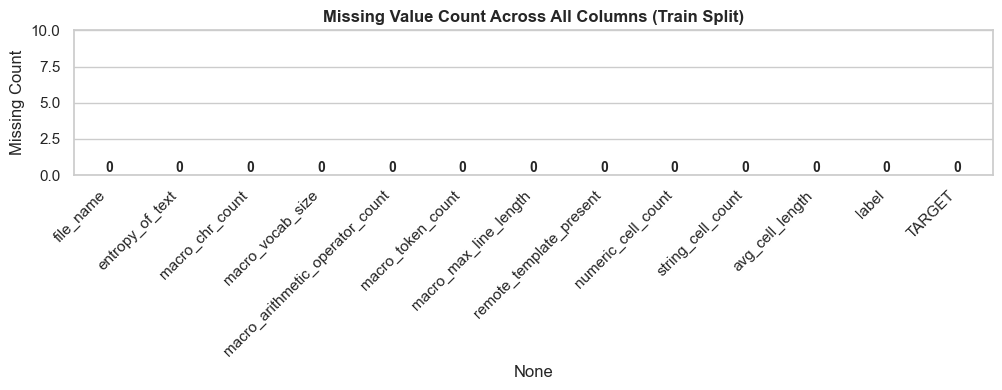

In [43]:
# Check missing values of all columns
missing = train.isnull().sum()

plt.figure(figsize=(10, 4))
ax = sns.barplot(x=missing.index, y=missing.values, color="#3498db")
plt.title("Missing Value Count Across All Columns (Train Split)", fontweight="bold")
plt.ylabel("Missing Count")
plt.xticks(rotation=45, ha="right")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')
plt.ylim(0, 10)
plt.tight_layout()
plt.show()


<a id="sec3_2" name="sec3_2"></a>
### 3.2 Visualization and Analysis of Each Feature
Inspect skewness, distributions, and class separation.


<a id="sec3_2_1" name="sec3_2_1"></a>
#### 3.2.1 Skewness & Distribution Evenness Assessment
Evaluate Fisher-Pearson skewness coefficient for the 9 core Excel features.


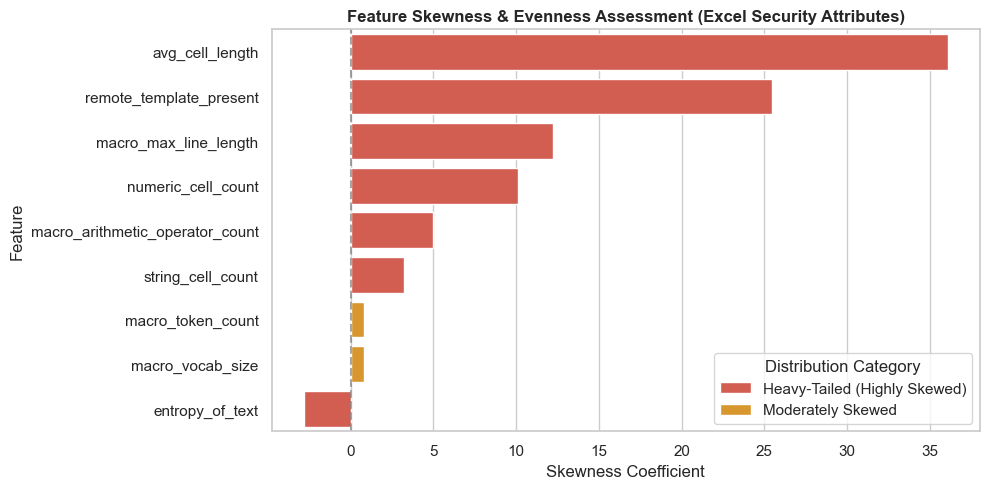

,Feature,Skewness,Distribution Category
0,avg_cell_length,36.0754,Heavy-Tailed (Highly Skewed)
1,remote_template_present,25.4722,Heavy-Tailed (Highly Skewed)
2,macro_max_line_length,12.2386,Heavy-Tailed (Highly Skewed)
3,numeric_cell_count,10.0847,Heavy-Tailed (Highly Skewed)
4,macro_arithmetic_operator_count,4.9468,Heavy-Tailed (Highly Skewed)
5,string_cell_count,3.2382,Heavy-Tailed (Highly Skewed)
6,macro_token_count,0.8239,Moderately Skewed
7,macro_vocab_size,0.8239,Moderately Skewed
8,entropy_of_text,-2.8305,Heavy-Tailed (Highly Skewed)


In [44]:
# Assess distribution evenness and skewness for each feature
skewness_series = train[core_features].skew().sort_values(ascending=False)

def classify_evenness(skew):
    abs_s = abs(skew)
    if abs_s < 0.5:
        return "Even / Symmetrical"
    elif abs_s <= 1.0:
        return "Moderately Skewed"
    else:
        return "Heavy-Tailed (Highly Skewed)"

evenness_df = pd.DataFrame({
    "Feature": skewness_series.index,
    "Skewness": skewness_series.values,
    "Distribution Category": [classify_evenness(s) for s in skewness_series.values]
})

plt.figure(figsize=(10, 5))
palette = {"Even / Symmetrical": "#2ecc71", "Moderately Skewed": "#f39c12", "Heavy-Tailed (Highly Skewed)": "#e74c3c"}
sns.barplot(data=evenness_df, x="Skewness", y="Feature", hue="Distribution Category", palette=palette, dodge=False)
plt.title("Feature Skewness & Evenness Assessment (Excel Security Attributes)", fontweight="bold")
plt.xlabel("Skewness Coefficient")
plt.axvline(0, color="gray", linestyle="--", alpha=0.7)
plt.legend(title="Distribution Category")
plt.tight_layout()
plt.show()

display(evenness_df)


<a id="sec3_2_2" name="sec3_2_2"></a>
#### 3.2.2 Full Feature Distribution Overview (Grid Visualization)
Examine raw histograms and KDE for all 9 attributes.


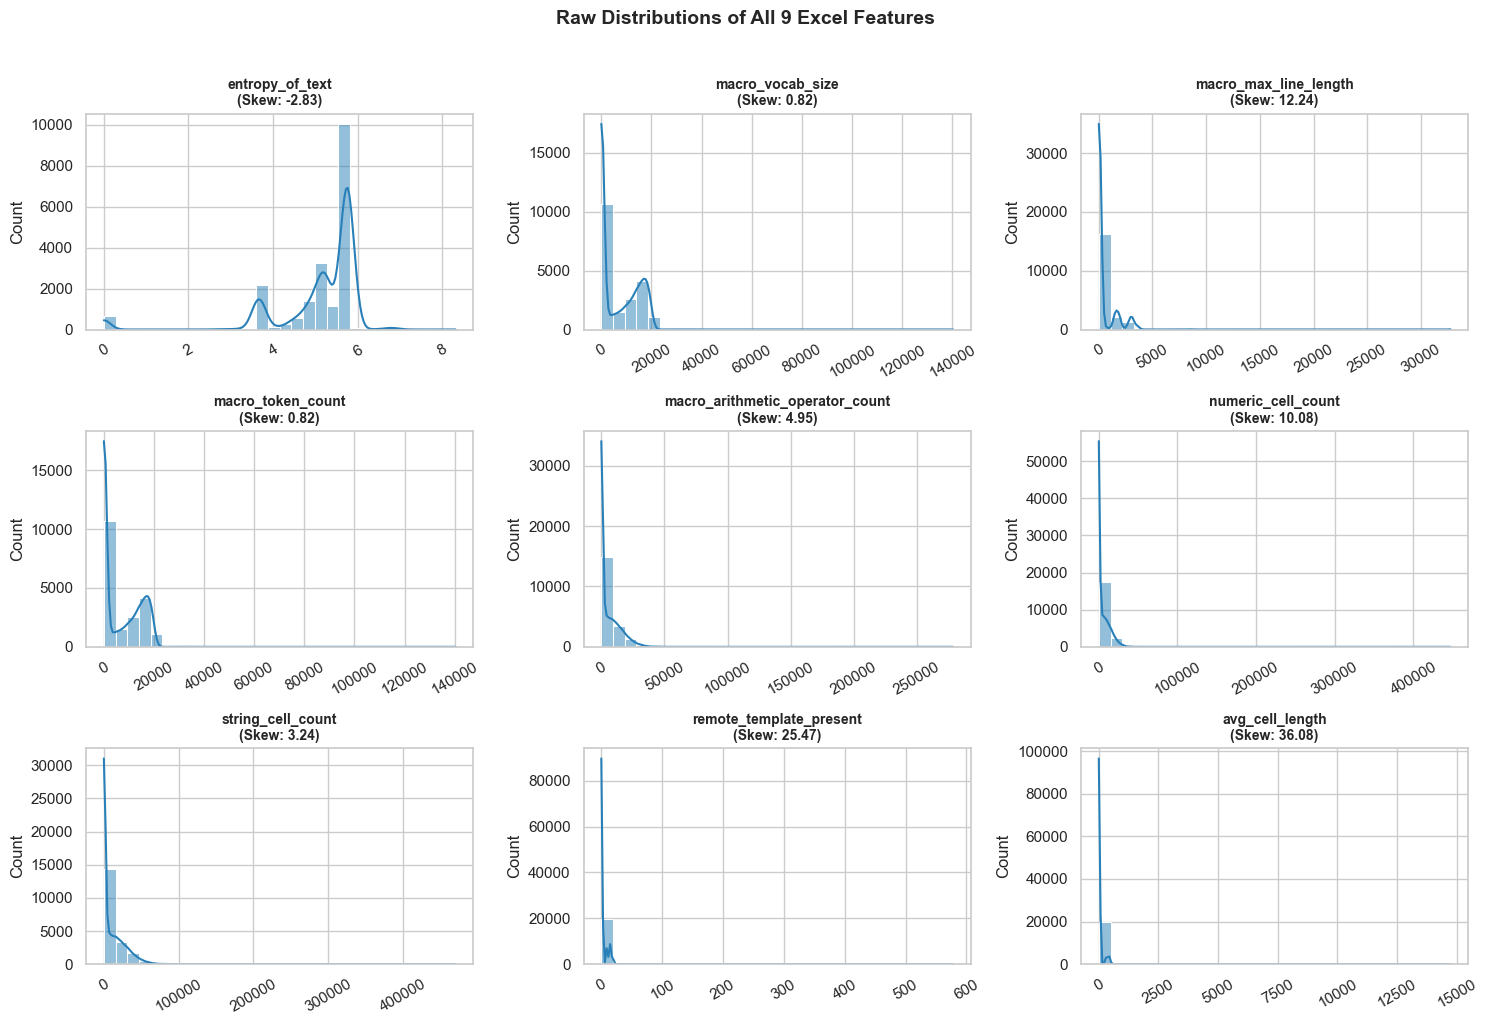

In [45]:
# Grid visualization of raw distributions for all 9 attributes
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(core_features):
    ax = axes[idx]
    sns.histplot(train[col], kde=True, ax=ax, color="#2980b9", bins=30)
    ax.set_title(f"{col}\n(Skew: {train[col].skew():.2f})", fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Raw Distributions of All 9 Excel Features", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


<a id="sec3_2_3" name="sec3_2_3"></a>
#### 3.2.3 TARGET Column (Class Evenness)
Visualize the target distribution.


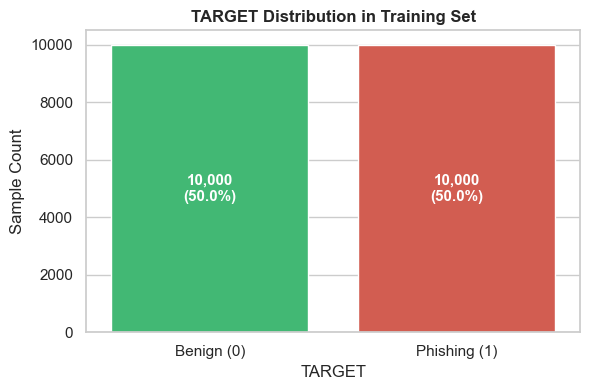

In [46]:
# The distribution of the target (Benign vs Phishing)
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=train, x="TARGET", hue="TARGET", palette=["#2ecc71", "#e74c3c"], legend=False)
plt.title("TARGET Distribution in Training Set", fontweight="bold")
ax.set_xticks([0, 1], labels=["Benign (0)", "Phishing (1)"])
plt.ylabel("Sample Count")

total = len(train)
for p in ax.patches:
    count = int(p.get_height())
    pct = count / total * 100
    ax.annotate(f"{count:,}\n({pct:.1f}%)", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


<a id="sec3_2_4" name="sec3_2_4"></a>
#### 3.2.4 Macro Complexity Attributes (`macro_token_count` & `macro_vocab_size`)
Compare the lexical complexity of VBA macros across classes.


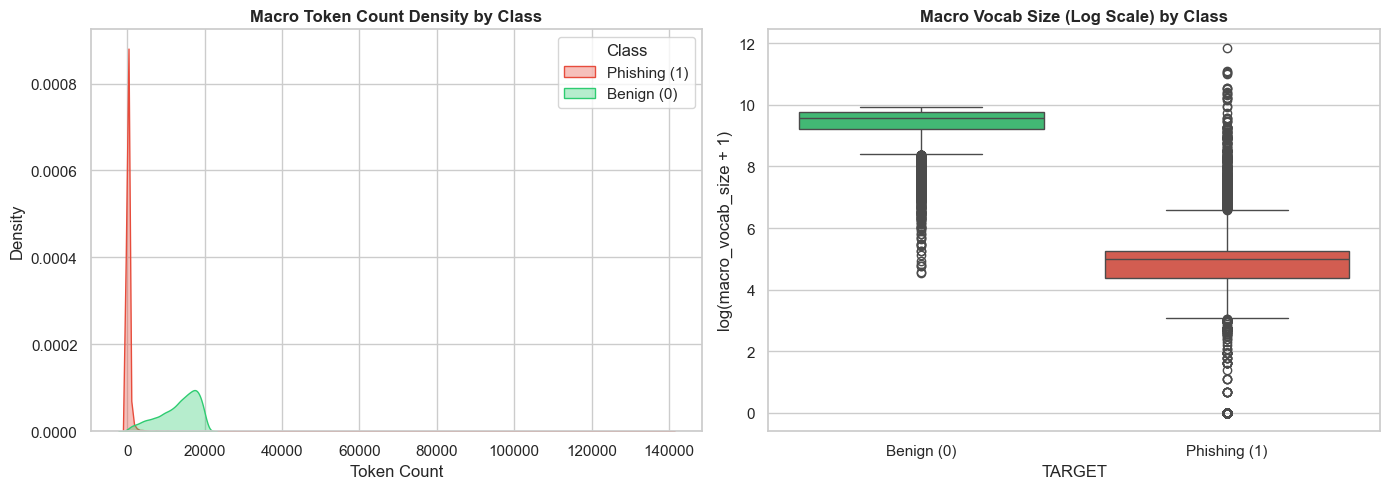

In [47]:
# Detailed inspection of macro token count and vocabulary size
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=train, x="macro_token_count", hue="TARGET", common_norm=False,
            palette=["#2ecc71", "#e74c3c"], fill=True, ax=axes[0], alpha=0.35)
axes[0].set_title("Macro Token Count Density by Class", fontweight="bold")
axes[0].set_xlabel("Token Count")
axes[0].legend(["Phishing (1)", "Benign (0)"], title="Class")

sns.boxplot(data=train, x="TARGET", y=np.log1p(train["macro_vocab_size"]),
            hue="TARGET", palette=["#2ecc71", "#e74c3c"], legend=False, ax=axes[1])
axes[1].set_title("Macro Vocab Size (Log Scale) by Class", fontweight="bold")
axes[1].set_xticks([0, 1], labels=["Benign (0)", "Phishing (1)"])
axes[1].set_ylabel("log(macro_vocab_size + 1)")

plt.tight_layout()
plt.show()


<a id="sec3_2_5" name="sec3_2_5"></a>
#### 3.2.5 Heavy-Tailed Attributes: Raw vs. Logarithmic Transformation
Compare raw vs log-transformed distributions for skewed attributes.


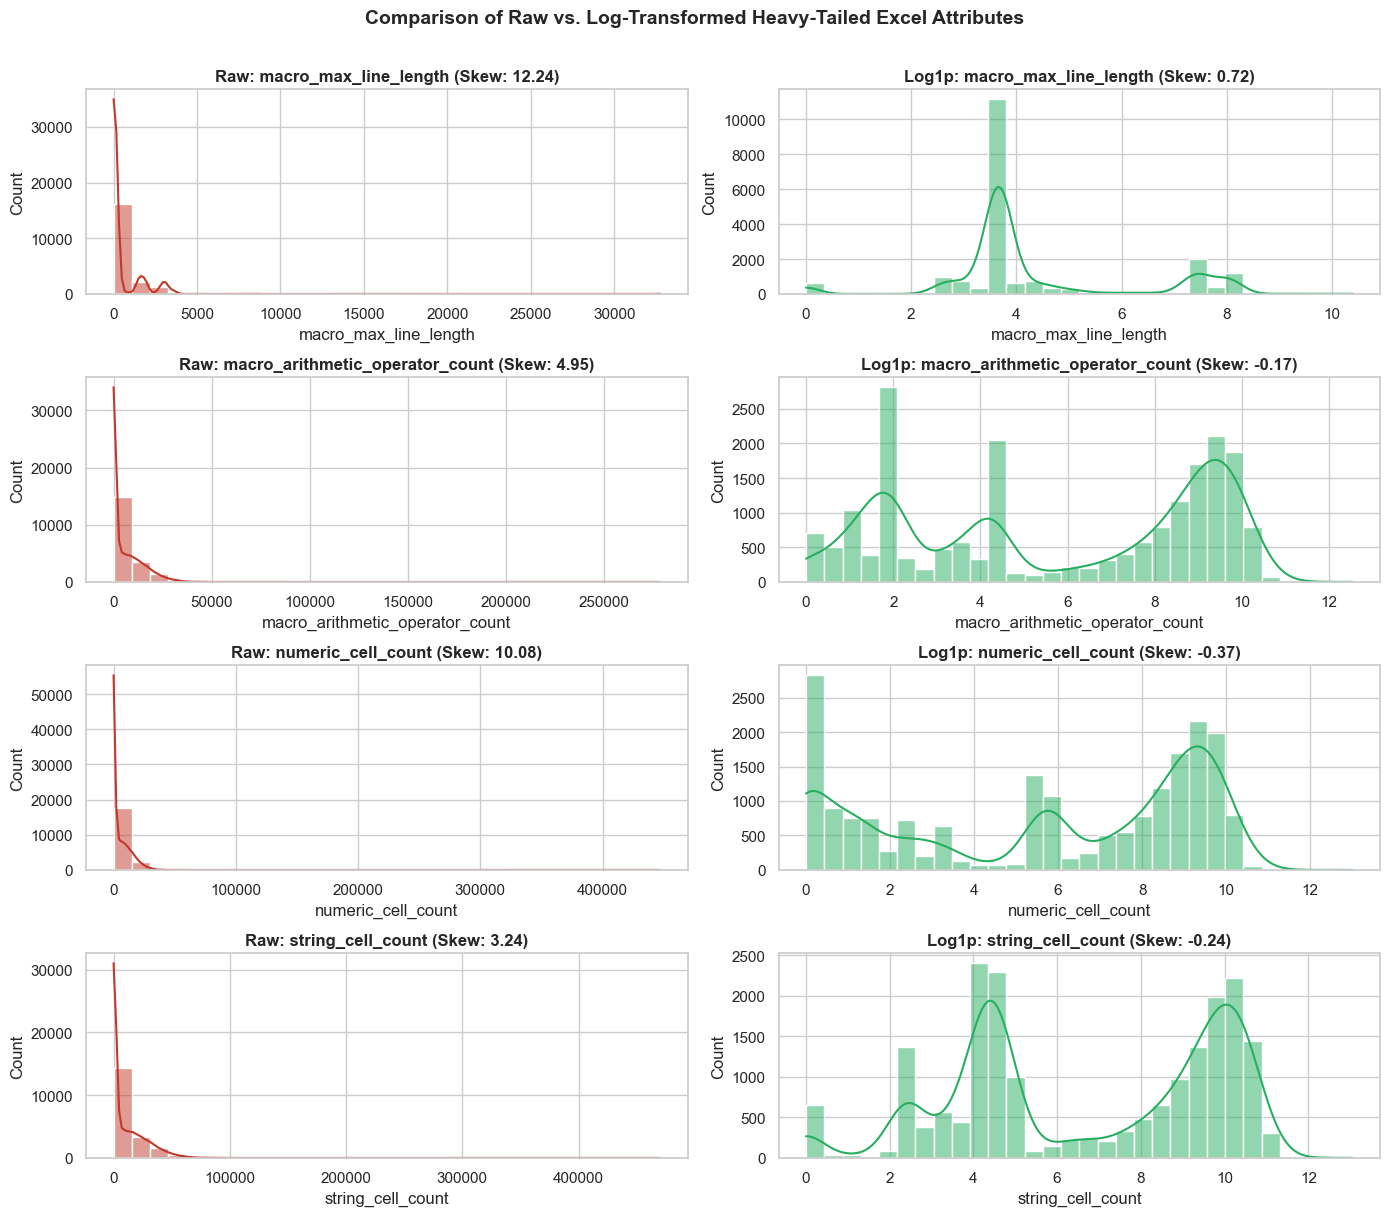

In [48]:
# Raw vs Log-Transformed comparison for heavy-tailed structural attributes
heavy_cols = ["macro_max_line_length", "macro_arithmetic_operator_count", "numeric_cell_count", "string_cell_count"]

fig, axes = plt.subplots(len(heavy_cols), 2, figsize=(14, 12))

for i, col in enumerate(heavy_cols):
    sns.histplot(train[col], kde=True, ax=axes[i, 0], color="#c0392b", bins=30)
    axes[i, 0].set_title(f"Raw: {col} (Skew: {train[col].skew():.2f})", fontweight="bold")
    
    log_vals = np.log1p(train[col])
    sns.histplot(log_vals, kde=True, ax=axes[i, 1], color="#27ae60", bins=30)
    axes[i, 1].set_title(f"Log1p: {col} (Skew: {log_vals.skew():.2f})", fontweight="bold")

plt.suptitle("Comparison of Raw vs. Log-Transformed Heavy-Tailed Excel Attributes", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


<a id="sec3_2_6" name="sec3_2_6"></a>
#### 3.2.6 Cell Structure & Remote Template Infiltration
Examine text entropy and remote template presence by class.


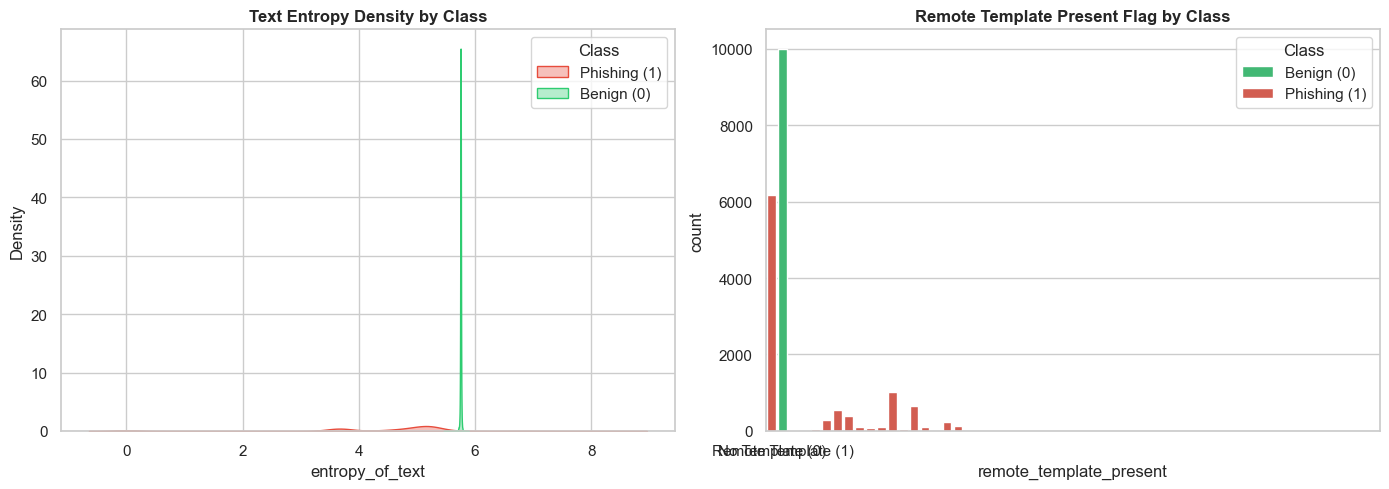

In [49]:
# Cell structure & remote template presence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=train, x="entropy_of_text", hue="TARGET", common_norm=False,
            palette=["#2ecc71", "#e74c3c"], fill=True, ax=axes[0], alpha=0.35)
axes[0].set_title("Text Entropy Density by Class", fontweight="bold")
axes[0].legend(["Phishing (1)", "Benign (0)"], title="Class")

sns.countplot(data=train, x="remote_template_present", hue="TARGET",
              palette=["#2ecc71", "#e74c3c"], ax=axes[1])
axes[1].set_title("Remote Template Present Flag by Class", fontweight="bold")
axes[1].set_xticks([0, 1], labels=["No Template (0)", "Remote Template (1)"])
axes[1].legend(["Benign (0)", "Phishing (1)"], title="Class")

plt.tight_layout()
plt.show()


<a id="sec3_2_7" name="sec3_2_7"></a>
#### 3.2.7 Comprehensive Evenness Summary Table & Correlation Heatmap
Compute feature correlations with `TARGET`.


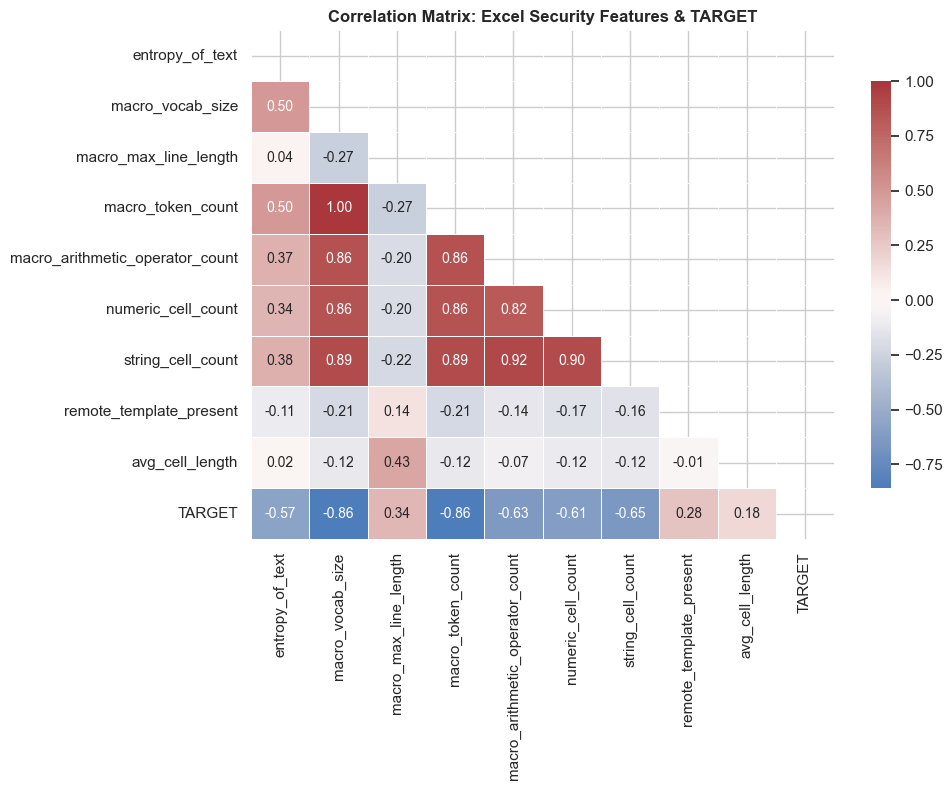

,Pearson Correlation (r)
macro_max_line_length,0.3363
remote_template_present,0.2773
avg_cell_length,0.1786
entropy_of_text,-0.5703
numeric_cell_count,-0.6096
macro_arithmetic_operator_count,-0.6344
string_cell_count,-0.6514
macro_token_count,-0.8591
macro_vocab_size,-0.8591


In [50]:
# Correlation heatmap and summary table
corr_matrix = train[core_features + ["TARGET"]].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", center=0,
            mask=mask, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix: Excel Security Features & TARGET", fontweight="bold")
plt.tight_layout()
plt.show()

top_corr = corr_matrix["TARGET"].drop("TARGET").sort_values(ascending=False)
display(pd.DataFrame({"Pearson Correlation (r)": top_corr}))


<a id="sec3_3" name="sec3_3"></a>
### 3.3 Summary Findings & Next Steps
- Macro features (`macro_vocab_size`, `macro_token_count`, `macro_arithmetic_operator_count`) are primary discriminators.
- Text entropy and remote template presence provide strong non-linear signals.
- Models will be trained with `StandardScaler` to ensure numerical stability.


<a id="sec4" name="sec4"></a>
## 4. Preprocessing and Feature Creation
Construct log-transformed representations and standardize features.


In [51]:
# Preprocessing: engineer log-transformed attributes
train_proc = train.copy()
test_proc = test.copy()

for col in ["macro_max_line_length", "macro_arithmetic_operator_count", "numeric_cell_count", "string_cell_count"]:
    train_proc[f"{col}_log"] = np.log1p(train_proc[col])
    test_proc[f"{col}_log"] = np.log1p(test_proc[col])

print(f"Engineered log features added. Feature count: {train_proc.shape[1] - 2} attributes.")


Engineered log features added. Feature count: 15 attributes.


<a id="sec5" name="sec5"></a>

## 5. Building the Machine Learning Models

We implement a rigorous, leakage-resistant **75%/25% train/test split**, followed by **5-fold cross-validation** across 6 model architectures:
- Logistic Regression, Decision Tree, Random Forest
- XGBoost, LightGBM, Neural Network (MLP)

We then tune the Random Forest via `RandomizedSearchCV` and export the full production bundle.

### Pipeline Stages
1. **75/25 Train/Test Split** — Stratified, no data snooping
2. **5-Fold Cross-Validation** — All 6 model architectures
3. **RF Hyperparameter Tuning** — `RandomizedSearchCV` (15 iterations)
4. **Comprehensive Model Comparison** — ROC-AUC, PR-AUC, F1, Accuracy
5. **Final Model Assembly** — 6 models fitted on full dev set
6. **Export** — Models + Scaler + CSVs + Confusion Matrix Grid


<a id="sec5_1" name="sec5_1"></a>

### 5.1 Leakage-Resistant 75%/25% Train/Test Split

Stratified split from the complete `raw_df`. The **25% test set is completely untouched** until final evaluation — no CV, no tuning, no visualization uses it.


In [52]:
# ============================================================
# LEAKAGE-RESISTANT 75% / 25% TRAIN / TEST SPLIT
# ============================================================
# We split from 'df' (which has file_name + core_features + TARGET)
# to prevent data snooping. The scaler fits only inside CV folds.

RANDOM_SEED = 42

print(f"Total dataset     : {len(df):,} samples")
print(f"Phishing (1)      : {(df['TARGET']==1).sum():,}")
print(f"Benign  (0)       : {(df['TARGET']==0).sum():,}")

# Stratified 75/25 split
X_raw = df[core_features].copy()
y_raw = df["TARGET"].values

X_dev, X_test, y_dev, y_test, idx_dev, idx_test = train_test_split(
    X_raw, y_raw, np.arange(len(df)), test_size=0.25, stratify=y_raw, random_state=RANDOM_SEED
)

df_dev  = df.iloc[idx_dev].reset_index(drop=True)
df_test = df.iloc[idx_test].reset_index(drop=True)

print(f"\nDevelopment Set (Train + CV): {len(df_dev):,} samples ({len(df_dev)/len(df)*100:.1f}%)")
print(f"Untouched Final Test Set     : {len(df_test):,} samples ({len(df_test)/len(df)*100:.1f}%)")
print(f"\n[OK] Excel dataset split complete - Development set will be used for all CV and tuning.")



Total dataset     : 20,000 samples
Phishing (1)      : 10,000
Benign  (0)       : 10,000

Development Set (Train + CV): 15,000 samples (75.0%)
Untouched Final Test Set     : 5,000 samples (25.0%)

[OK] Excel dataset split complete - Development set will be used for all CV and tuning.


<a id="sec5_2" name="sec5_2"></a>

### 5.2 Cross-Validation Framework & Baseline Models

Import all ML libraries and evaluate 3 baseline models via 5-fold stratified cross-validation. The `StandardScaler` is fitted **inside** each fold to prevent data leakage.


In [53]:
import json
import time

# Scikit-learn - full suite
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score, confusion_matrix
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import joblib

RANDOM_SEED = 42

# ============================================================
# 5-FOLD CROSS-VALIDATION FRAMEWORK
# ============================================================
cv_5fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

def run_cross_validation(estimator, X_data, y_data):
    metrics = {"roc_auc": [], "pr_auc": [], "accuracy": [], "precision": [], "recall": [], "f1": []}
    for tr_idx, val_idx in cv_5fold.split(X_data, y_data):
        scaler = StandardScaler()
        X_tr  = scaler.fit_transform(X_data[tr_idx])
        X_val = scaler.transform(X_data[val_idx])
        y_tr, y_val = y_data[tr_idx], y_data[val_idx]
        
        m = estimator()
        m.fit(X_tr, y_tr)
        probs = m.predict_proba(X_val)[:, 1]
        preds = (probs >= 0.5).astype(int)
        
        metrics["roc_auc"].append(roc_auc_score(y_val, probs))
        metrics["pr_auc"].append(average_precision_score(y_val, probs))
        metrics["accuracy"].append(accuracy_score(y_val, preds))
        metrics["precision"].append(precision_score(y_val, preds, zero_division=0))
        metrics["recall"].append(recall_score(y_val, preds, zero_division=0))
        metrics["f1"].append(f1_score(y_val, preds, zero_division=0))
    return {k: (np.mean(v), np.std(v)) for k, v in metrics.items()}

# --- Baseline models ---
baseline_models = {
    "Logistic Regression":    lambda: LogisticRegression(random_state=RANDOM_SEED, max_iter=1000),
    "Decision Tree":          lambda: DecisionTreeClassifier(random_state=RANDOM_SEED, max_depth=8),
    "Random Forest (Baseline)": lambda: RandomForestClassifier(random_state=RANDOM_SEED, max_depth=10, n_estimators=100, n_jobs=-1),
}

print("\n" + "="*70)
print("Baseline Models - 5-Fold Cross-Validation (Development Set)")
print("="*70)
baseline_cv_results = {}
for name, fn in baseline_models.items():
    t0 = time.time()
    res = run_cross_validation(fn, X_dev.values, y_dev)
    baseline_cv_results[name] = res
    print(f"{name:30s} | AUC: {res['roc_auc'][0]:.4f} +/- {res['roc_auc'][1]:.4f} | PR-AUC: {res['pr_auc'][0]:.4f} | F1: {res['f1'][0]:.4f} | {time.time()-t0:.1f}s")



Baseline Models - 5-Fold Cross-Validation (Development Set)
Logistic Regression            | AUC: 0.9981 +/- 0.0014 | PR-AUC: 0.9989 | F1: 0.9952 | 0.2s
Decision Tree                  | AUC: 0.9995 +/- 0.0003 | PR-AUC: 0.9994 | F1: 0.9995 | 0.2s
Random Forest (Baseline)       | AUC: 1.0000 +/- 0.0000 | PR-AUC: 1.0000 | F1: 0.9998 | 1.4s


<a id="sec5_3" name="sec5_3"></a>

### 5.3 Advanced Models: XGBoost, LightGBM & Neural Network (MLP)

State-of-the-art gradient boosting and deep learning models benchmarked using the same 5-fold CV framework.


In [54]:
# --- Advanced models: XGBoost, LightGBM, Neural Network (MLP) ---
advanced_models = {
    "XGBoost": lambda: XGBClassifier(
        random_state=RANDOM_SEED, max_depth=6, n_estimators=100, eval_metric="logloss", n_jobs=-1
    ),
    "LightGBM": lambda: LGBMClassifier(
        random_state=RANDOM_SEED, max_depth=6, n_estimators=100, verbose=-1, n_jobs=-1
    ),
    "Neural Network (MLP)": lambda: MLPClassifier(
        hidden_layer_sizes=(64, 32), activation="relu", solver="adam", alpha=1e-4,
        batch_size=64, learning_rate_init=0.01, max_iter=300, random_state=RANDOM_SEED,
        early_stopping=True, n_iter_no_change=50
    ),
}

print("\n" + "="*70)
print("Advanced Models - 5-Fold Cross-Validation (Development Set)")
print("="*70)
advanced_cv_results = {}
for name, fn in advanced_models.items():
    t0 = time.time()
    res = run_cross_validation(fn, X_dev.values, y_dev)
    advanced_cv_results[name] = res
    print(f"{name:30s} | AUC: {res['roc_auc'][0]:.4f} +/- {res['roc_auc'][1]:.4f} | PR-AUC: {res['pr_auc'][0]:.4f} | F1: {res['f1'][0]:.4f} | {time.time()-t0:.1f}s")



Advanced Models - 5-Fold Cross-Validation (Development Set)
XGBoost                        | AUC: 1.0000 +/- 0.0000 | PR-AUC: 1.0000 | F1: 0.9998 | 0.7s
LightGBM                       | AUC: 0.9999 +/- 0.0001 | PR-AUC: 0.9999 | F1: 0.9998 | 0.6s
Neural Network (MLP)           | AUC: 1.0000 +/- 0.0001 | PR-AUC: 1.0000 | F1: 0.9993 | 16.2s


<a id="sec5_4" name="sec5_4"></a>

### 5.4 Hyperparameter Optimization (Random Forest Tuning)

`RandomizedSearchCV` with 15 iterations and 5-fold CV to find optimal RF hyperparameters.


In [55]:
import json
# ============================================================
# HYPERPARAMETER OPTIMIZATION: RANDOM FOREST TUNING
# ============================================================
sc_tune = StandardScaler()
X_dev_std_tune = sc_tune.fit_transform(X_dev.values)

rf_param_dist = {
    "n_estimators":     [100, 150, 200],
    "max_depth":        [8, 12, 16, 20, None],
    "min_samples_split":[2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features":     ["sqrt", "log2", 0.5],
}

rf_random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=15,
    scoring="roc_auc",
    cv=cv_5fold,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
rf_random_search.fit(X_dev_std_tune, y_dev)
best_rf_params = rf_random_search.best_params_

print("Best Random Forest Hyperparameters Found:")
print(json.dumps(best_rf_params, indent=2))
print(f"Best CV ROC-AUC: {rf_random_search.best_score_:.4f}")

tuned_rf_results = run_cross_validation(
    lambda: RandomForestClassifier(**best_rf_params, random_state=RANDOM_SEED, n_jobs=-1),
    X_dev.values, y_dev
)
print(f"\nTuned RF 5-Fold CV: AUC = {tuned_rf_results['roc_auc'][0]:.4f} +/- {tuned_rf_results['roc_auc'][1]:.4f} | F1 = {tuned_rf_results['f1'][0]:.4f}")


Best Random Forest Hyperparameters Found:
{
  "n_estimators": 200,
  "min_samples_split": 2,
  "min_samples_leaf": 1,
  "max_features": 0.5,
  "max_depth": 16
}
Best CV ROC-AUC: 1.0000

Tuned RF 5-Fold CV: AUC = 1.0000 +/- 0.0000 | F1 = 0.9998


<a id="sec5_5" name="sec5_5"></a>

### 5.5 Comprehensive Model Comparison Table

Aggregate all 5-fold CV results into a single benchmark leaderboard.


In [56]:
# ============================================================
# COMPREHENSIVE MODEL COMPARISON TABLE
# ============================================================
all_model_results = {
    **baseline_cv_results,
    "Tuned Random Forest": tuned_rf_results,
    **advanced_cv_results,
}

comparison_table = []
for name, r in all_model_results.items():
    comparison_table.append({
        "Model":                name,
        "ROC-AUC (Mean +/- Std)": f"{r['roc_auc'][0]:.4f} +/- {r['roc_auc'][1]:.4f}",
        "PR-AUC (Mean)":        f"{r['pr_auc'][0]:.4f}",
        "Accuracy (Mean)":      f"{r['accuracy'][0]*100:.2f}%",
        "Precision (Mean)":     f"{r['precision'][0]:.4f}",
        "Recall (Mean)":        f"{r['recall'][0]:.4f}",
        "F1-Score (Mean)":      f"{r['f1'][0]:.4f}",
    })

comparison_df = pd.DataFrame(comparison_table)
display(comparison_df)


,Model,ROC-AUC (Mean +/- Std),PR-AUC (Mean),Accuracy (Mean),Precision (Mean),Recall (Mean),F1-Score (Mean)
0,Logistic Regression,0.9981 +/- 0.0014,0.9989,99.52%,0.9964,0.9940,0.9952
1,Decision Tree,0.9995 +/- 0.0003,0.9994,99.95%,0.9997,0.9993,0.9995
2,Random Forest (Baseline),1.0000 +/- 0.0000,1.0000,99.98%,0.9996,1.0000,0.9998
3,Tuned Random Forest,1.0000 +/- 0.0000,1.0000,99.98%,0.9996,1.0000,0.9998
4,XGBoost,1.0000 +/- 0.0000,1.0000,99.98%,0.9999,0.9997,0.9998
5,LightGBM,0.9999 +/- 0.0001,0.9999,99.98%,0.9999,0.9997,0.9998
6,Neural Network (MLP),1.0000 +/- 0.0001,1.0000,99.93%,0.9999,0.9987,0.9993


<a id="sec5_6" name="sec5_6"></a>

### 5.6 Final Model Assembly

Fit all 6 production models on the **complete Development set** using the final `StandardScaler`.


In [57]:
# ============================================================
# FINAL MODEL PIPELINE: FIT ALL 6 PRODUCTION MODELS
# ============================================================
final_scaler = StandardScaler()
X_dev_final_std  = final_scaler.fit_transform(X_dev.values)
X_test_final_std = final_scaler.transform(X_test.values)

final_rf = RandomForestClassifier(**best_rf_params, random_state=RANDOM_SEED, n_jobs=-1)
final_rf.fit(X_dev_final_std, y_dev)

dt_final = DecisionTreeClassifier(random_state=RANDOM_SEED, max_depth=8).fit(X_dev_final_std, y_dev)
lr_final = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000).fit(X_dev_final_std, y_dev)

mlp_final = MLPClassifier(
    hidden_layer_sizes=(64, 32), activation="relu", solver="adam", alpha=1e-4,
    batch_size=64, learning_rate_init=0.001, max_iter=300, random_state=RANDOM_SEED,
    early_stopping=True, n_iter_no_change=15
).fit(X_dev_final_std, y_dev)

xgb_final = XGBClassifier(
    random_state=RANDOM_SEED, eval_metric="logloss",
    n_estimators=150, max_depth=6, learning_rate=0.1
).fit(X_dev_final_std, y_dev)

lgb_final = LGBMClassifier(
    random_state=RANDOM_SEED, n_estimators=150, max_depth=6, learning_rate=0.1, verbose=-1
).fit(X_dev_final_std, y_dev)

# Quick baseline check
test_probs = final_rf.predict_proba(X_test_final_std)[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

print(f"[OK] All 6 production models trained on full Development set ({len(y_dev):,} samples)!")
print(f"Tuned RF  | Test ROC-AUC: {roc_auc_score(y_test, test_probs):.4f} | Accuracy: {accuracy_score(y_test, test_preds)*100:.2f}%")


[OK] All 6 production models trained on full Development set (15,000 samples)!
Tuned RF  | Test ROC-AUC: 1.0000 | Accuracy: 99.96%


<a id="sec6" name="sec6"></a>

## 6. Model Export & Prediction Results

Save all 6 production models, scaler, feature schema, and metadata to `models/excel/` and `InterfaceExplainPhish/models/excel/`. Also export train/test CSV splits (raw + standardized) and submission predictions.


In [58]:
import json
# ============================================================
# SAVE PRODUCTION MODELS + STANDARDIZED CSV DATASETS
# ============================================================
current_dir = Path(os.getcwd())

dest_folders = [
    current_dir / "models" / "excel",
    current_dir / "InterfaceExplainPhish" / "models" / "excel",
    Path("models/excel"),
    Path("InterfaceExplainPhish/models/excel"),
]

valid_destinations = set()
for folder in dest_folders:
    try:
        folder.mkdir(parents=True, exist_ok=True)
        valid_destinations.add(folder.resolve())
    except Exception:
        pass

for target_dir in valid_destinations:
    joblib.dump(final_rf,     target_dir / "rf_model.joblib")
    joblib.dump(dt_final,     target_dir / "dt_model.joblib")
    joblib.dump(mlp_final,    target_dir / "mlp_model.joblib")
    joblib.dump(xgb_final,    target_dir / "xgb_model.joblib")
    joblib.dump(lgb_final,    target_dir / "lgb_model.joblib")
    joblib.dump(lr_final,     target_dir / "lr_model.joblib")
    joblib.dump(final_scaler, target_dir / "scaler.joblib")

    with open(target_dir / "selected_features.json", "w", encoding="utf-8") as fj:
        json.dump(core_features, fj, indent=2)

    meta = {
        "format": "excel",
        "models": ["random_forest", "decision_tree", "neural_network_mlp", "xgboost", "lightgbm", "logistic_regression"],
        "n_features": len(core_features),
        "features": core_features,
        "best_rf_params": best_rf_params,
        "test_metrics": {
            "roc_auc":    round(float(roc_auc_score(y_test, test_probs)), 4),
            "accuracy":   round(float(accuracy_score(y_test, test_preds)), 4),
            "f1":         round(float(f1_score(y_test, test_preds)), 4),
        },
    }
    with open(target_dir / "metadata.json", "w", encoding="utf-8") as fj:
        json.dump(meta, fj, indent=2)

    print(f"Saved production bundle -> {target_dir}")

# --- Export Standardized & Raw CSV Splits ---
train_std_df = pd.DataFrame(X_dev_final_std, columns=core_features)
train_std_df.insert(0, "file_name", df_dev["file_name"].values)
train_std_df["TARGET"] = y_dev

test_std_df = pd.DataFrame(X_test_final_std, columns=core_features)
test_std_df.insert(0, "file_name", df_test["file_name"].values)
test_std_df["TARGET"] = y_test

train_raw_df = df_dev[["file_name"] + core_features + ["TARGET"]].copy()
test_raw_df  = df_test[["file_name"] + core_features + ["TARGET"]].copy()

sample_sub = pd.DataFrame({
    "file_name": df_test["file_name"].values,
    "TARGET":    test_probs,
})

export_directories = [
    current_dir / "output",
    current_dir / "output" / "excel output",
    current_dir / "googleCollab" / "output",
    current_dir / "googleCollab" / "output" / "excel output",
]

for out_d in export_directories:
    out_d.mkdir(parents=True, exist_ok=True)
    train_std_df.to_csv(out_d / "train_standardized.csv", index=False)
    test_std_df.to_csv(out_d  / "test_standardized.csv",  index=False)
    train_raw_df.to_csv(out_d / "train.csv",              index=False)
    test_raw_df.to_csv(out_d  / "test.csv",               index=False)
    sample_sub.to_csv(out_d   / "submission.csv",         index=False)

print("\n[OK] Successfully saved datasets & predictions:")
print(f" - train_standardized.csv  shape: {train_std_df.shape}")
print(f" - test_standardized.csv   shape: {test_std_df.shape}")
print(f" - train.csv               shape: {train_raw_df.shape}")
print(f" - test.csv                shape: {test_raw_df.shape}")
print(f" - submission.csv          shape: {sample_sub.shape}")


Saved production bundle -> D:\codingProject\ExplainPhish\googleCollab\models\excel
Saved production bundle -> D:\codingProject\ExplainPhish\googleCollab\InterfaceExplainPhish\models\excel

[OK] Successfully saved datasets & predictions:
 - train_standardized.csv  shape: (15000, 11)
 - test_standardized.csv   shape: (5000, 11)
 - train.csv               shape: (15000, 11)
 - test.csv                shape: (5000, 11)
 - submission.csv          shape: (5000, 2)


<a id="sec7" name="sec7"></a>

## 7. Final Test Set Evaluation & Confusion Matrix Grid

Evaluate all 7 model variants (including baseline RF) against the **untouched 25% test set**. Visualize a comprehensive confusion matrix grid for all models.



=== FINAL TEST SET EVALUATION - Excel Phishing Detection (All 7 Models) ===
  Logistic Regression            | AUC=0.9989 | Acc=99.52% | F1=0.9952 | FPR=0.36% | FNR=0.60%
  Decision Tree                  | AUC=0.9998 | Acc=99.98% | F1=0.9998 | FPR=0.04% | FNR=0.00%
  Neural Network (MLP)           | AUC=1.0000 | Acc=99.84% | F1=0.9984 | FPR=0.12% | FNR=0.20%
  Random Forest (Baseline)       | AUC=1.0000 | Acc=99.96% | F1=0.9996 | FPR=0.08% | FNR=0.00%
  Tuned Random Forest            | AUC=1.0000 | Acc=99.96% | F1=0.9996 | FPR=0.08% | FNR=0.00%
  XGBoost                        | AUC=1.0000 | Acc=100.00% | F1=1.0000 | FPR=0.00% | FNR=0.00%
  LightGBM                       | AUC=1.0000 | Acc=99.98% | F1=0.9998 | FPR=0.00% | FNR=0.04%


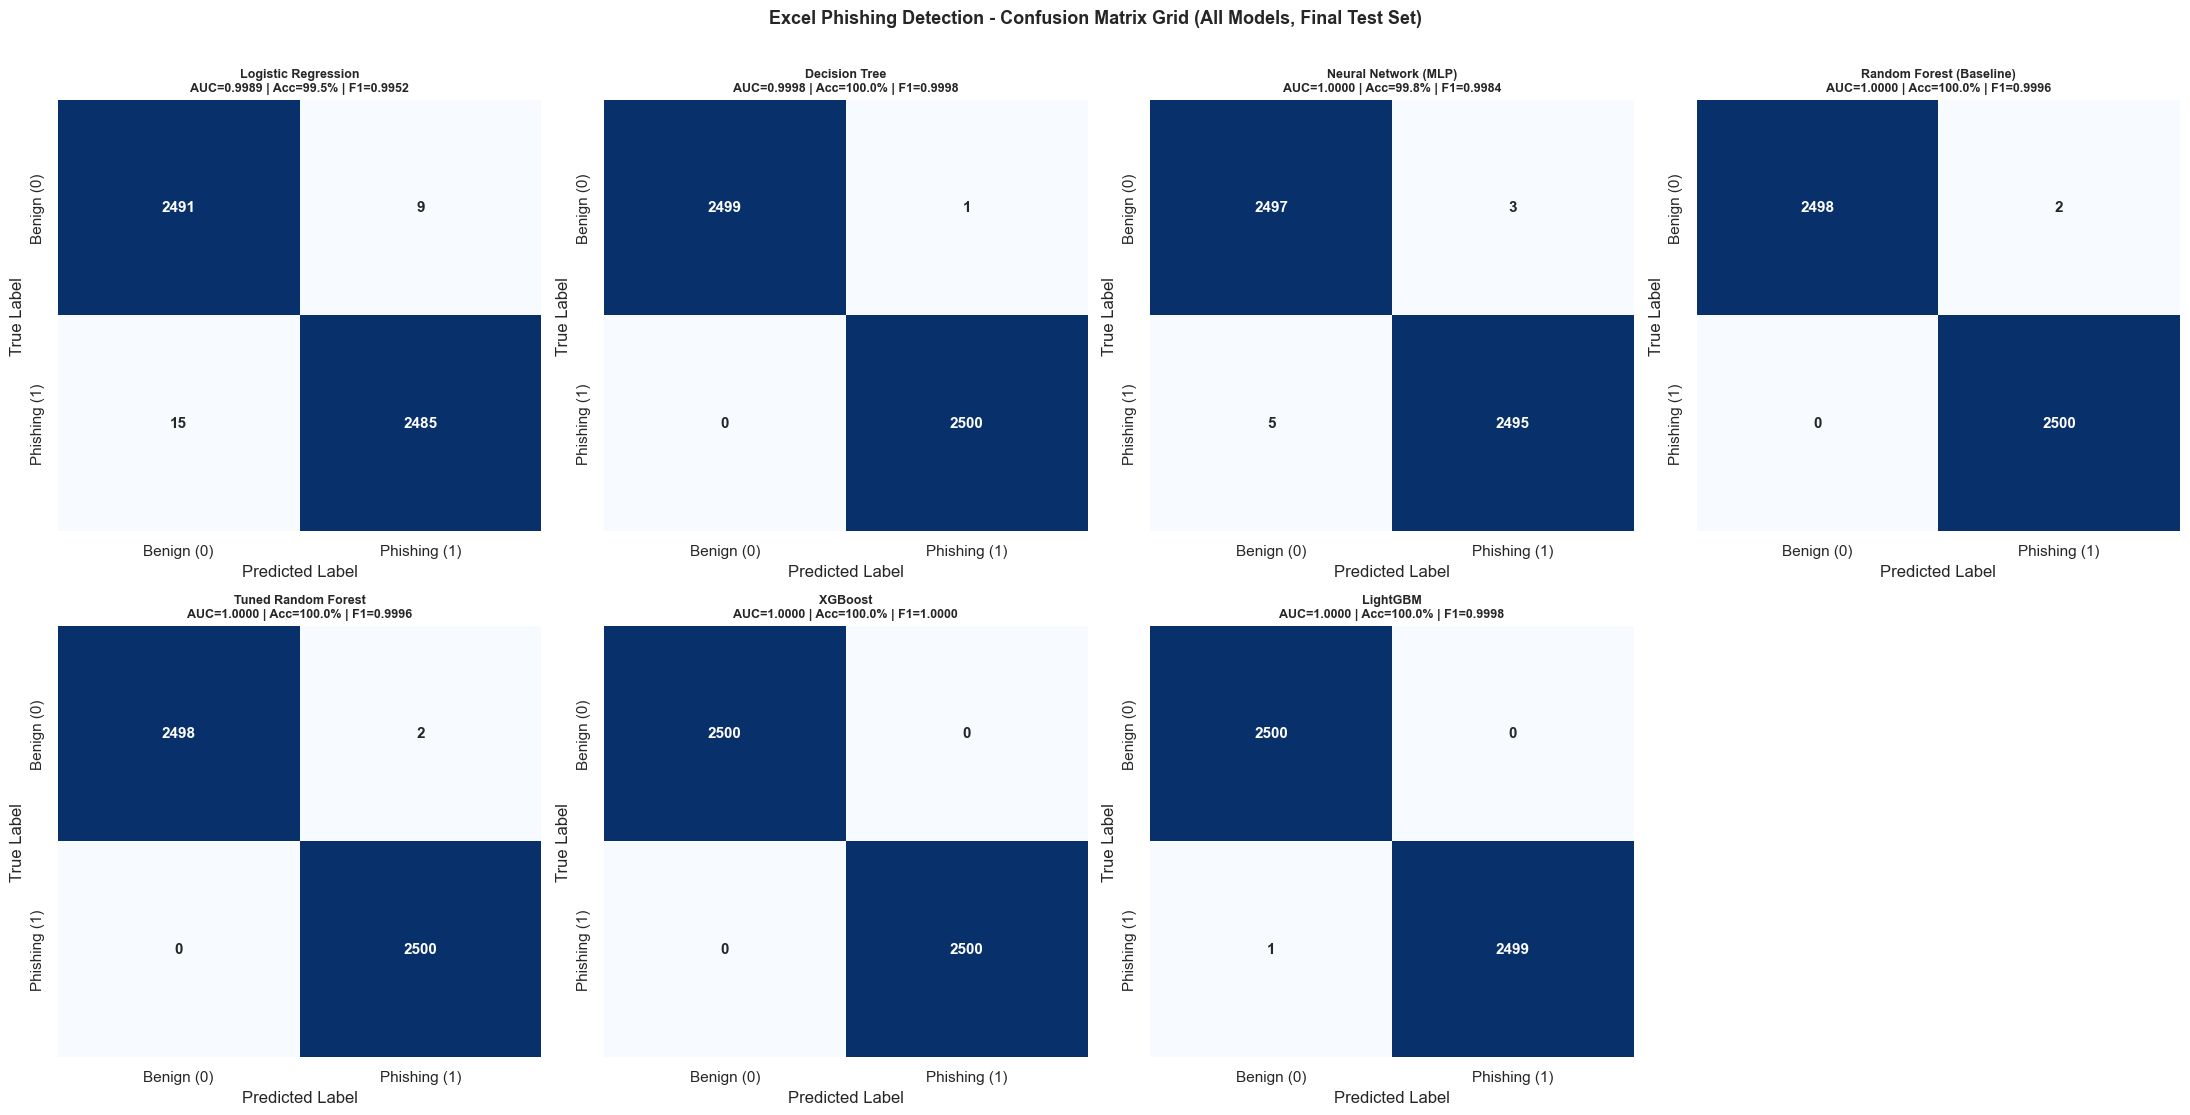

,Model,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1-Score,TN,FP,FN,TP,FPR,FNR
0,Logistic Regression,0.9989,0.9992,99.52%,0.9964,0.9940,0.9952,2491,9,15,2485,0.36%,0.60%
1,Decision Tree,0.9998,0.9996,99.98%,0.9996,1.0000,0.9998,2499,1,0,2500,0.04%,0.00%
2,Neural Network (MLP),1.0000,1.0000,99.84%,0.9988,0.9980,0.9984,2497,3,5,2495,0.12%,0.20%
3,Random Forest (Baseline),1.0000,1.0000,99.96%,0.9992,1.0000,0.9996,2498,2,0,2500,0.08%,0.00%
4,Tuned Random Forest,1.0000,1.0000,99.96%,0.9992,1.0000,0.9996,2498,2,0,2500,0.08%,0.00%
5,XGBoost,1.0000,1.0000,100.00%,1.0000,1.0000,1.0000,2500,0,0,2500,0.00%,0.00%
6,LightGBM,1.0000,1.0000,99.98%,1.0000,0.9996,0.9998,2500,0,1,2499,0.00%,0.04%


In [59]:
# ============================================================
# FINAL TEST SET EVALUATION & CONFUSION MATRIX GRID (ALL MODELS)
# ============================================================
all_eval_models = {
    "Logistic Regression":      LogisticRegression(random_state=RANDOM_SEED, max_iter=1000),
    "Decision Tree":            DecisionTreeClassifier(random_state=RANDOM_SEED, max_depth=8),
    "Neural Network (MLP)":     mlp_final,
    "Random Forest (Baseline)": RandomForestClassifier(random_state=RANDOM_SEED, n_estimators=100, max_depth=None),
    "Tuned Random Forest":      final_rf,
    "XGBoost":                  XGBClassifier(random_state=RANDOM_SEED, eval_metric="logloss", n_estimators=150, max_depth=6, learning_rate=0.1),
    "LightGBM":                 LGBMClassifier(random_state=RANDOM_SEED, n_estimators=150, max_depth=6, learning_rate=0.1, verbose=-1),
}

test_metrics_summary = []
fig, axes = plt.subplots(2, 4, figsize=(22, 11))
axes = axes.flatten()

print("\n" + "=" * 80)
print("=== FINAL TEST SET EVALUATION - Excel Phishing Detection (All 7 Models) ===")
print("=" * 80)

for idx, (m_name, model) in enumerate(all_eval_models.items()):
    if m_name not in ["Tuned Random Forest", "Neural Network (MLP)"]:
        model.fit(X_dev_final_std, y_dev)
    m_probs = model.predict_proba(X_test_final_std)[:, 1]
    m_preds = (m_probs >= 0.5).astype(int)

    cm           = confusion_matrix(y_test, m_preds)
    tn, fp, fn, tp = cm.ravel()
    auc   = roc_auc_score(y_test, m_probs)
    prauc = average_precision_score(y_test, m_probs)
    acc   = accuracy_score(y_test, m_preds)
    prec  = precision_score(y_test, m_preds, zero_division=0)
    rec   = recall_score(y_test, m_preds, zero_division=0)
    f1    = f1_score(y_test, m_preds, zero_division=0)
    fpr_r = fp / (fp + tn) * 100 if (fp + tn) > 0 else 0
    fnr_r = fn / (fn + tp) * 100 if (fn + tp) > 0 else 0

    test_metrics_summary.append({
        "Model":     m_name,
        "ROC-AUC":   round(auc,   4),
        "PR-AUC":    round(prauc, 4),
        "Accuracy":  f"{acc*100:.2f}%",
        "Precision": round(prec, 4),
        "Recall":    round(rec,  4),
        "F1-Score":  round(f1,   4),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "FPR": f"{fpr_r:.2f}%",
        "FNR": f"{fnr_r:.2f}%",
    })

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[idx],
                xticklabels=["Benign (0)", "Phishing (1)"],
                yticklabels=["Benign (0)", "Phishing (1)"],
                annot_kws={"size": 11, "weight": "bold"})
    axes[idx].set_title(
        f"{m_name}\nAUC={auc:.4f} | Acc={acc*100:.1f}% | F1={f1:.4f}",
        fontsize=9, fontweight="bold"
    )
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")

    print(f"  {m_name:30s} | AUC={auc:.4f} | Acc={acc*100:.2f}% | F1={f1:.4f} | FPR={fpr_r:.2f}% | FNR={fnr_r:.2f}%")

# Hide the unused 8th subplot (7 models, 2x4 = 8 slots)
for j in range(len(all_eval_models), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    f"Excel Phishing Detection - Confusion Matrix Grid (All Models, Final Test Set)",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

# Summary table
test_summary_df = pd.DataFrame(test_metrics_summary)
display(test_summary_df)


<a id="sec8" name="sec8"></a>

## 8. Research Limitations & Future Roadmap

### Limitations Identified:
1. **Static Feature Extraction**: Features are extracted from static Excel file properties only; dynamic runtime analysis is not performed.
2. **Dataset Scope**: Trained on CIC-Trap4Phish2025; adversarial or zero-day Excel phishing samples may have novel feature patterns.
3. **Class Balance**: The 50/50 balanced dataset may not reflect real-world prevalence.

### Future Work:
- **Temporal Drift Monitoring**: Retrain periodically on fresh phishing data feeds
- **Adversarial Robustness Testing**: Perturb features to assess model fragility
- **SHAP Explainability**: Add SHAP TreeExplainer for feature-level model interpretation
- **Ensemble Calibration**: Apply Platt scaling or isotonic regression
